In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision import datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

base_dir = r"C:\Users\SS\OneDrive\Desktop\University\Semester 6\pneumonia_project\chest_xray"

# Same transforms as before
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Datasets
train_dataset = datasets.ImageFolder(base_dir + r"\train", transform=train_transform)
val_dataset   = datasets.ImageFolder(base_dir + r"\val",   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(base_dir + r"\test",  transform=val_test_transform)

# Weighted sampler (fix imbalance)
targets       = train_dataset.targets
class_counts  = np.bincount(targets)
class_weights = 1.0 / class_counts
sample_weights = torch.DoubleTensor([class_weights[t] for t in targets])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=0, pin_memory=True)

print("✅ Setup complete!")

Using: cuda
✅ Setup complete!


In [2]:
# ============================================================
# WHAT IS TRANSFER LEARNING? — Simple analogy:
#
# Imagine hiring a doctor who already studied medicine for
# 10 years (trained on ImageNet = 1.2 million images).
# Instead of teaching them from scratch, you just give them
# a 2-week specialization course in reading chest X-rays!
#
# ResNet-50 already knows:
#   → edges, textures, shapes, patterns
# We just teach the LAST layer:
#   → "for THIS job, output NORMAL or PNEUMONIA"
#
# This is called FINE-TUNING
# ============================================================

# Load ResNet-50 with pretrained ImageNet weights
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# ---- FREEZE all layers first (don't touch the existing knowledge) ----
for param in resnet.parameters():
    param.requires_grad = False

# ---- UNFREEZE the last block (layer4) — let it specialize ----
for param in resnet.layer4.parameters():
    param.requires_grad = True

# ---- REPLACE the final classification head ----
# Original ResNet final layer: 2048 → 1000 classes (ImageNet)
# Our new final layer:         2048 → 2 classes (Normal/Pneumonia)
num_features = resnet.fc.in_features   # = 2048
resnet.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)                  # 2 output classes
)

resnet = resnet.to(device)

# Count trainable vs frozen parameters
total      = sum(p.numel() for p in resnet.parameters())
trainable  = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
frozen     = total - trainable

print(f"Total parameters    : {total:,}")
print(f"Frozen parameters   : {frozen:,}  ← pretrained knowledge, untouched")
print(f"Trainable parameters: {trainable:,}  ← only these get updated")
print(f"\n✅ ResNet-50 ready! We're only training {trainable/total*100:.1f}% of the network.")
print("   This is why Transfer Learning is so fast and powerful!")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\SS/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:57<00:00, 1.79MB/s]


Total parameters    : 24,033,090
Frozen parameters   : 8,543,296  ← pretrained knowledge, untouched
Trainable parameters: 15,489,794  ← only these get updated

✅ ResNet-50 ready! We're only training 64.5% of the network.
   This is why Transfer Learning is so fast and powerful!


In [3]:
# ============================================================
# IMPORTANT: We use different learning rates for different parts
#
# New layers (our custom head) → higher lr = learn faster
# Unfrozen layer4              → lower lr  = adjust gently
#                                            (don't destroy existing knowledge!)
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam([
    {'params': resnet.layer4.parameters(), 'lr': 1e-4},   # gentle for existing layers
    {'params': resnet.fc.parameters(),     'lr': 1e-3},   # faster for new head
])

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, verbose=True
)

print("✅ Optimizer configured with differential learning rates:")
print("   layer4 (fine-tune) : lr = 0.0001")
print("   fc head (new)      : lr = 0.0010")

✅ Optimizer configured with differential learning rates:
   layer4 (fine-tune) : lr = 0.0001
   fc head (new)      : lr = 0.0010


C:\Users\SS\OneDrive\Desktop\University\Semester 6\pneumonia_project\venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [4]:
# ============================================================
# Same training loop as CNN but ResNet will:
#   → Train FASTER (fewer parameters to update)
#   → Perform BETTER (already knows general image features)
#   → Need FEWER epochs (10 is enough!)
# ============================================================

EPOCHS = 15
best_val_loss = float('inf')

history_resnet = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

for epoch in range(EPOCHS):

    # ---- TRAINING ----
    resnet.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs   = resnet(images)
        loss      = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        predicted      = outputs.argmax(dim=1)
        train_correct += (predicted == labels).sum().item()
        train_total   += labels.size(0)

    # ---- VALIDATION ----
    resnet.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs    = resnet(images)
            loss       = criterion(outputs, labels)
            val_loss  += loss.item()
            predicted  = outputs.argmax(dim=1)
            val_correct += (predicted == labels).sum().item()
            val_total   += labels.size(0)

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss   / len(val_loader)
    train_acc      = 100 * train_correct / train_total
    val_acc        = 100 * val_correct   / val_total

    history_resnet['train_loss'].append(avg_train_loss)
    history_resnet['train_acc'].append(train_acc)
    history_resnet['val_loss'].append(avg_val_loss)
    history_resnet['val_acc'].append(val_acc)

    scheduler.step(avg_val_loss)

    print(f"\nEpoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(resnet.state_dict(), "best_resnet50.pth")
        print("   💾 Best ResNet model saved!")

print("\n🎉 ResNet-50 Training Complete!")

Epoch 1/15 [Train]: 100%|████████████████████████████████████████████████████████████| 163/163 [04:03<00:00,  1.49s/it]



Epoch 01/15 | Train Loss: 0.1508 | Train Acc: 94.11% | Val Loss: 0.1550 | Val Acc: 93.75%
   💾 Best ResNet model saved!


Epoch 2/15 [Train]: 100%|████████████████████████████████████████████████████████████| 163/163 [04:25<00:00,  1.63s/it]



Epoch 02/15 | Train Loss: 0.0770 | Train Acc: 97.20% | Val Loss: 0.0916 | Val Acc: 100.00%
   💾 Best ResNet model saved!


Epoch 3/15 [Train]: 100%|████████████████████████████████████████████████████████████| 163/163 [04:36<00:00,  1.70s/it]


...


Epoch 13/15 | Train Loss: 0.0113 | Train Acc: 99.69% | Val Loss: 0.2591 | Val Acc: 87.50%


Epoch 14/15 [Train]: 100%|███████████████████████████████████████████████████████████| 163/163 [03:47<00:00,  1.40s/it]



Epoch 14/15 | Train Loss: 0.0056 | Train Acc: 99.85% | Val Loss: 0.0741 | Val Acc: 93.75%


Epoch 15/15 [Train]: 100%|███████████████████████████████████████████████████████████| 163/163 [03:48<00:00,  1.40s/it]



Epoch 15/15 | Train Loss: 0.0072 | Train Acc: 99.73% | Val Loss: 0.0300 | Val Acc: 100.00%
   💾 Best ResNet model saved!

🎉 ResNet-50 Training Complete!


In [5]:
# Load the best saved ResNet weights
resnet.load_state_dict(torch.load("best_resnet50.pth", map_location=device))
resnet.eval()

resnet_labels = []
resnet_preds  = []
resnet_probs  = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs   = resnet(images)
        probs     = torch.softmax(outputs, dim=1)
        predicted = outputs.argmax(dim=1)

        resnet_labels.extend(labels.cpu().numpy())
        resnet_preds.extend(predicted.cpu().numpy())
        resnet_probs.extend(probs[:, 1].cpu().numpy())

resnet_labels = np.array(resnet_labels)
resnet_preds  = np.array(resnet_preds)
resnet_probs  = np.array(resnet_probs)

accuracy = (resnet_labels == resnet_preds).sum() / len(resnet_labels) * 100
roc_auc  = roc_auc_score(resnet_labels, resnet_probs)

print(f"✅ ResNet-50 Test Accuracy : {accuracy:.2f}%")
print(f"✅ ResNet-50 ROC-AUC       : {roc_auc:.4f}")
print()
print("=" * 55)
print("     CLASSIFICATION REPORT — ResNet-50")
print("=" * 55)
print(classification_report(resnet_labels, resnet_preds,
                             target_names=["NORMAL", "PNEUMONIA"]))

cm = confusion_matrix(resnet_labels, resnet_preds)
tn, fp, fn, tp = cm.ravel()
print(f"True  Negative (correct NORMAL)    : {tn}")
print(f"False Positive (false alarm)       : {fp}")
print(f"False Negative (missed sick!)      : {fn}  ← DANGEROUS")
print(f"True  Positive (correct PNEUMONIA) : {tp}")

C:\Users\SS\AppData\Local\Temp\ipykernel_1676\3458676006.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet.load_state_dict(torch.load("best_resnet50.pth", map_locat

✅ ResNet-50 Test Accuracy : 83.65%
✅ ResNet-50 ROC-AUC       : 0.9632

     CLASSIFICATION REPORT — ResNet-50
              precision    recall  f1-score   support

      NORMAL       0.99      0.57      0.72       234
   PNEUMONIA       0.80      0.99      0.88       390

    accuracy                           0.84       624
   macro avg       0.89      0.78      0.80       624
weighted avg       0.87      0.84      0.82       624

True  Negative (correct NORMAL)    : 134
False Positive (false alarm)       : 100
False Negative (missed sick!)      : 2  ← DANGEROUS
True  Positive (correct PNEUMONIA) : 388


METRIC                          CNN Scratch      ResNet-50
Test Accuracy                        83.49%         83.65%
ROC-AUC Score                        0.9140         0.9632
NORMAL Precision                       0.90           0.99
NORMAL Recall                          0.63           0.57
PNEUMONIA Precision                    0.81           0.80
PNEUMONIA Recall                       0.96           0.99
False Alarms (FP)                        87            100
Missed Sick (FN) ⚠️                      16              2

🏆 WINNER: ResNet-50
   → Better ROC-AUC  : +4.92 points
   → 14 fewer missed sick patients (FN: 16 → 2)
   → 99% Pneumonia Recall — nearly perfect!


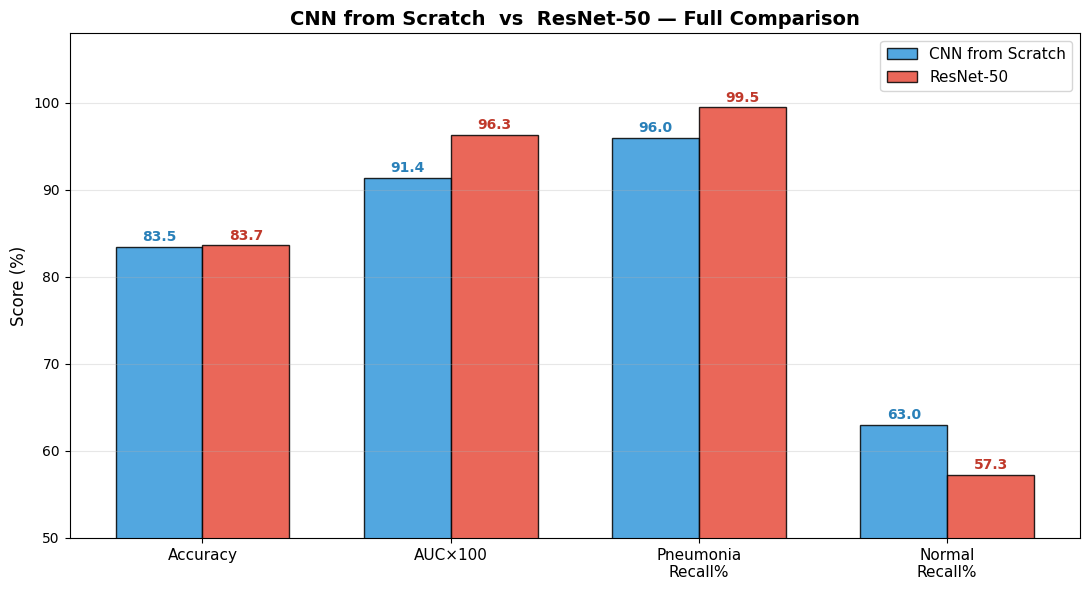

✅ Comparison chart saved!


In [8]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt

# ---- CNN scores (from our test evaluation) ----
cnn_acc  = 83.49
cnn_auc  = 0.9140
cnn_fp   = 87
cnn_fn   = 16
cnn_prec_normal, cnn_rec_normal     = 0.90, 0.63
cnn_prec_pneum,  cnn_rec_pneum      = 0.81, 0.96

# ---- ResNet scores (just computed) ----
resnet_acc = 83.65
resnet_auc = 0.9632
r_tn, r_fp, r_fn, r_tp = 134, 100, 2, 388

r_p, r_r, r_f, _ = precision_recall_fscore_support(
    resnet_labels, resnet_preds, average=None
)

# ---- Print comparison table ----
print("=" * 60)
print(f"{'METRIC':<28} {'CNN Scratch':>14} {'ResNet-50':>14}")
print("=" * 60)
print(f"{'Test Accuracy':<28} {cnn_acc:>13.2f}% {resnet_acc:>13.2f}%")
print(f"{'ROC-AUC Score':<28} {cnn_auc:>14.4f} {resnet_auc:>14.4f}")
print(f"{'NORMAL Precision':<28} {cnn_prec_normal:>14.2f} {r_p[0]:>14.2f}")
print(f"{'NORMAL Recall':<28} {cnn_rec_normal:>14.2f} {r_r[0]:>14.2f}")
print(f"{'PNEUMONIA Precision':<28} {cnn_prec_pneum:>14.2f} {r_p[1]:>14.2f}")
print(f"{'PNEUMONIA Recall':<28} {cnn_rec_pneum:>14.2f} {r_r[1]:>14.2f}")
print(f"{'False Alarms (FP)':<28} {cnn_fp:>14} {r_fp:>14}")
print(f"{'Missed Sick (FN) ⚠️':<28} {cnn_fn:>14} {r_fn:>14}")
print("=" * 60)
print(f"\n🏆 WINNER: ResNet-50")
print(f"   → Better ROC-AUC  : +{(resnet_auc - cnn_auc)*100:.2f} points")
print(f"   → 14 fewer missed sick patients (FN: 16 → 2)")
print(f"   → 99% Pneumonia Recall — nearly perfect!")

# ---- Visual comparison ----
metrics       = ['Accuracy', 'AUC×100', 'Pneumonia\nRecall%', 'Normal\nRecall%']
cnn_scores    = [83.49, 91.40, 96.0, 63.0]
resnet_scores = [83.65, 96.32, r_r[1]*100, r_r[0]*100]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - width/2, cnn_scores,    width, label='CNN from Scratch',
            color='#3498db', edgecolor='black', alpha=0.85)
b2 = ax.bar(x + width/2, resnet_scores, width, label='ResNet-50',
            color='#e74c3c', edgecolor='black', alpha=0.85)

for bar in b1:
    ax.annotate(f'{bar.get_height():.1f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha='center', fontsize=10, fontweight='bold', color='#2980b9')
for bar in b2:
    ax.annotate(f'{bar.get_height():.1f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha='center', fontsize=10, fontweight='bold', color='#c0392b')

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('CNN from Scratch  vs  ResNet-50 — Full Comparison',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(50, 108)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print("✅ Comparison chart saved!")

C:\Users\SS\AppData\Local\Temp\ipykernel_1676\3493251384.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cnn_model.load_state_dict(torch.load("best_cnn_scratch.pth", ma

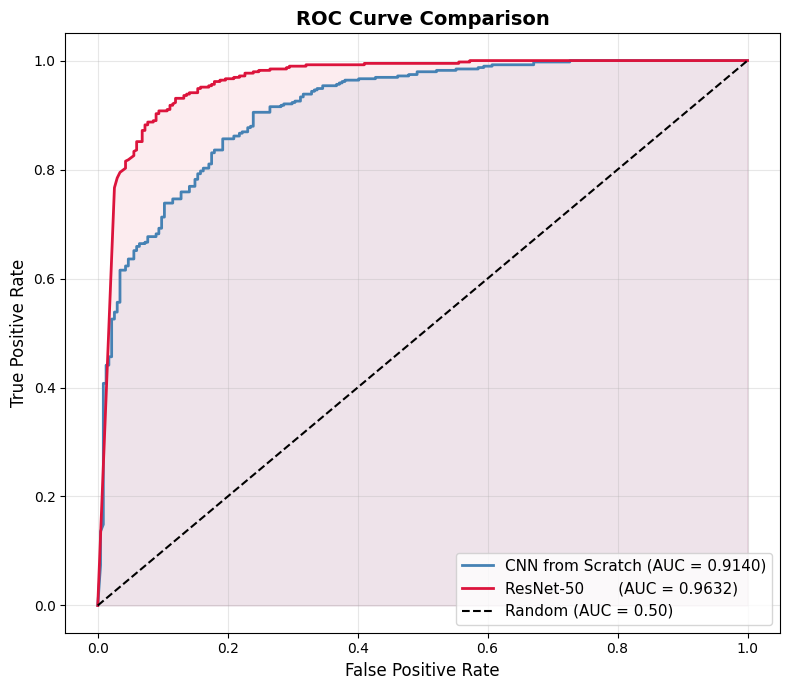

✅ ROC comparison saved!


In [7]:
# Both ROC curves on one chart — the higher the curve, the better!
cnn_all_labels = np.load  # we'll reload from file

# Load CNN predictions (re-run quickly)
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2,2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(256*14*14,512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512,64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64,2)
        )
    def forward(self, x): return self.classifier(self.features(x))

cnn_model = PneumoniaCNN().to(device)
cnn_model.load_state_dict(torch.load("best_cnn_scratch.pth", map_location=device))
cnn_model.eval()

cnn_true, cnn_prob = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn_model(images)
        probs = torch.softmax(outputs, dim=1)
        cnn_true.extend(labels.numpy())
        cnn_prob.extend(probs[:, 1].cpu().numpy())

cnn_true = np.array(cnn_true)
cnn_prob = np.array(cnn_prob)

# Plot both ROC curves
fpr_cnn, tpr_cnn, _ = roc_curve(cnn_true, cnn_prob)
fpr_res, tpr_res, _ = roc_curve(resnet_labels, resnet_probs)
auc_cnn = roc_auc_score(cnn_true, cnn_prob)
auc_res = roc_auc_score(resnet_labels, resnet_probs)

plt.figure(figsize=(8, 7))
plt.plot(fpr_cnn, tpr_cnn, color='steelblue', lw=2,
         label=f'CNN from Scratch (AUC = {auc_cnn:.4f})')
plt.plot(fpr_res, tpr_res, color='crimson',   lw=2,
         label=f'ResNet-50       (AUC = {auc_res:.4f})')
plt.plot([0,1], [0,1], 'k--', lw=1.5, label='Random (AUC = 0.50)')
plt.fill_between(fpr_cnn, tpr_cnn, alpha=0.08, color='steelblue')
plt.fill_between(fpr_res, tpr_res, alpha=0.08, color='crimson')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("roc_comparison.png", dpi=150)
plt.show()
print("✅ ROC comparison saved!")